In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### Dataset Overview

##### Import Dataset

In [4]:
df = pd.read_csv("customer_shopping_behavior.csv")

In [5]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [6]:
df.shape

(5050, 17)

In [7]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,5050.000000,5050.000000,4494.000000,4449.000000,4502.000000
mean,2519.570891,44.150495,144.765236,3.668195,25.221901
std,1470.402964,15.282328,275.590101,0.865357,14.521635
min,1.000000,18.000000,10.120000,1.000000,0.000000
25%,1252.250000,31.000000,41.000000,3.000000,13.000000
50%,2499.500000,44.000000,65.000000,3.700000,25.000000
75%,3740.750000,57.000000,89.000000,4.400000,38.000000
max,5099.000000,70.000000,1499.760000,5.000000,50.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   str    
 3   Item Purchased          5050 non-null   str    
 4   Category                5050 non-null   str    
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   str    
 7   Size                    4680 non-null   str    
 8   Color                   5050 non-null   str    
 9   Season                  5050 non-null   str    
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   str    
 12  Shipping Type           5050 non-null   str    
 13  Discount Applied        5050 non-null   str    
 14  Previous Purchases      4502 non-null   float64
 15

In [9]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

### Data Cleaning

In [11]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [12]:
df["Item Purchased"].unique()

<ArrowStringArray>
[   'T-shirt', 'Sunglasses',      'Shirt',     'Gloves',    'Jewelry',
     'Shorts',        'Hat',    'Handbag',      'Shoes',       'Coat',
     'Laptop',     'Hoodie',      'Phone',     'Jacket',      'Pants',
   'Backpack',      'Socks',      'Jeans',        'Bag',       'Belt',
      'Watch', 'Headphones',     'Blouse',    'Sandals',      'Skirt',
    'Sweater',      'Scarf',   'Sneakers',      'Boots',      'Dress']
Length: 30, dtype: str

In [13]:
df["Category"].unique()

<ArrowStringArray>
['Clothing', 'Accessories', 'Outerwear', 'Electronics', 'Footwear']
Length: 5, dtype: str

In [14]:
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

## Not show properly maping error

In [16]:
df.groupby('Category')["Item Purchased"].unique()

Category
Accessories               [Sunglasses, Gloves, Jewelry, Hat, Handbag, Phone, Backpack, Belt, Bag, Headphones, Scarf, Watch, Shirt, Shoes, Laptop]
Clothing       [T-shirt, Shirt, Shorts, Shoes, Hoodie, Phone, Pants, Socks, Jeans, Bag, Blouse, Skirt, Sweater, Watch, Laptop, Dress, Headphones]
Electronics                                                                                 [Laptop, Phone, Watch, Bag, Shoes, Shirt, Headphones]
Footwear                                                                                                        [Shoes, Sandals, Sneakers, Boots]
Outerwear                                                                                                                          [Coat, Jacket]
Name: Item Purchased, dtype: object

In [17]:
correct_mapping= {
    #clothing
    "T-shirt":"Clothing","Shirt":"Clothing","Shorts":"Clothing",
    "Hoodie":"Clothing","Pants":"Clothing","Socks":"Clothing",
    "Jeans":"Clothing","Blouse":"Clothing","Skirt":"Clothing",
    "Sweater":"Clothing","Dress":"Clothing",

    #Accessories
    "Sunglasses":"Accessories","Gloves":"Accessories","Jewelry":"Accessories",
    "Hat":"Accessories","Handbag":"Accessories","Backpack":"Accessories",
    "Belt":"Accessories","Scarf":"Accessories","Bag":"Accessories",

    #Electronics
    "Laptop":"Electronics","Phone":"Electronics","Headphones":"Electronics",
    "Watch":"Electronics",

    #Footwear
    "Shoes":"Footwear","Sandals":"Footwear",
    "Sneakers":"Footwear","Boots":"Footwear",

    #Outerwear
    "Coat":"Outerwear","Jacket":"Outerwear"
    
}

In [18]:
correct_mapping

{'T-shirt': 'Clothing',
 'Shirt': 'Clothing',
 'Shorts': 'Clothing',
 'Hoodie': 'Clothing',
 'Pants': 'Clothing',
 'Socks': 'Clothing',
 'Jeans': 'Clothing',
 'Blouse': 'Clothing',
 'Skirt': 'Clothing',
 'Sweater': 'Clothing',
 'Dress': 'Clothing',
 'Sunglasses': 'Accessories',
 'Gloves': 'Accessories',
 'Jewelry': 'Accessories',
 'Hat': 'Accessories',
 'Handbag': 'Accessories',
 'Backpack': 'Accessories',
 'Belt': 'Accessories',
 'Scarf': 'Accessories',
 'Bag': 'Accessories',
 'Laptop': 'Electronics',
 'Phone': 'Electronics',
 'Headphones': 'Electronics',
 'Watch': 'Electronics',
 'Shoes': 'Footwear',
 'Sandals': 'Footwear',
 'Sneakers': 'Footwear',
 'Boots': 'Footwear',
 'Coat': 'Outerwear',
 'Jacket': 'Outerwear'}

### Replace both column after correct maping

In [20]:
df['Category']=df['Item Purchased'].map(correct_mapping)

### after correct the maping data

In [22]:
df.groupby('Category')["Item Purchased"].unique()

Category
Accessories                 [Sunglasses, Gloves, Jewelry, Hat, Handbag, Backpack, Bag, Belt, Scarf]
Clothing       [T-shirt, Shirt, Shorts, Hoodie, Pants, Socks, Jeans, Blouse, Skirt, Sweater, Dress]
Electronics                                                      [Laptop, Phone, Watch, Headphones]
Footwear                                                          [Shoes, Sandals, Sneakers, Boots]
Outerwear                                                                            [Coat, Jacket]
Name: Item Purchased, dtype: object

### Treating Null

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   str    
 3   Item Purchased          5050 non-null   str    
 4   Category                5050 non-null   str    
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   str    
 7   Size                    4680 non-null   str    
 8   Color                   5050 non-null   str    
 9   Season                  5050 non-null   str    
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   str    
 12  Shipping Type           5050 non-null   str    
 13  Discount Applied        5050 non-null   str    
 14  Previous Purchases      4502 non-null   float64
 15

In [25]:
df['Size'].unique()

<ArrowStringArray>
['XL', 'M', 'L', 'S', nan]
Length: 5, dtype: str

#### nan is null value present

In [27]:
df.groupby('Category')['Size'].unique()

Category
Accessories    [M, L, S, XL, nan]
Clothing       [XL, M, S, L, nan]
Electronics    [nan, L, S, M, XL]
Footwear       [M, L, S, nan, XL]
Outerwear           [XL, L, S, M]
Name: Size, dtype: object

In [28]:
df.groupby('Item Purchased')['Size'].unique()

Item Purchased
Backpack           [M, S, L, XL]
Bag           [M, L, nan, XL, S]
Belt               [M, S, XL, L]
Blouse             [M, L, S, XL]
Boots              [L, M, XL, S]
Coat               [XL, M, S, L]
Dress              [XL, M, L, S]
Gloves             [L, M, S, XL]
Handbag            [S, XL, M, L]
Hat                [M, L, S, XL]
Headphones    [S, M, nan, L, XL]
Hoodie             [M, L, S, XL]
Jacket             [L, S, M, XL]
Jeans              [L, M, XL, S]
Jewelry            [L, XL, M, S]
Laptop        [nan, M, S, XL, L]
Pants              [L, M, XL, S]
Phone         [nan, L, S, M, XL]
Sandals            [M, S, L, XL]
Scarf              [M, L, S, XL]
Shirt         [M, XL, L, S, nan]
Shoes         [M, L, nan, XL, S]
Shorts             [S, M, L, XL]
Skirt              [S, L, M, XL]
Sneakers           [S, M, L, XL]
Socks              [M, XL, L, S]
Sunglasses         [M, L, S, XL]
Sweater            [M, S, L, XL]
T-shirt            [XL, M, S, L]
Watch         [nan, M, L, XL

In [29]:
# Treating Null values or Replacing all value in Electronics Category
df.loc[df['Category']=='Electronics','Size']="Not Applicable"

In [30]:
df.groupby('Category')['Size'].unique()

Category
Accessories    [M, L, S, XL, nan]
Clothing       [XL, M, S, L, nan]
Electronics      [Not Applicable]
Footwear       [M, L, S, nan, XL]
Outerwear           [XL, L, S, M]
Name: Size, dtype: object

In [31]:
# Treating Null values or Replacing all value in Accessories Category
df.loc[df['Category']=="Accessories","Size"]="Free Size"

In [32]:
df.groupby('Category')['Size'].unique()

Category
Accessories           [Free Size]
Clothing       [XL, M, S, L, nan]
Electronics      [Not Applicable]
Footwear       [M, L, S, nan, XL]
Outerwear           [XL, L, S, M]
Name: Size, dtype: object

In [33]:
# Treating Null Values or replacing all values in the Footwear category
df.loc[df["Category"]=="Footwear","Size"]="Not available"

In [34]:
df.groupby('Category')['Size'].unique()

Category
Accessories           [Free Size]
Clothing       [XL, M, S, L, nan]
Electronics      [Not Applicable]
Footwear          [Not available]
Outerwear           [XL, L, S, M]
Name: Size, dtype: object

### For Clothing section we use fill value to mode bcz it is categorical column thats why we cant use mean or median

In [36]:
df.loc[(df["Category"]=="Clothing") & (df["Size"].isnull()),"Size"] = df[df["Category"]=="Clothing"]["Size"].mode()[0]

In [37]:
df.groupby('Category')['Size'].unique()

Category
Accessories         [Free Size]
Clothing          [XL, M, S, L]
Electronics    [Not Applicable]
Footwear        [Not available]
Outerwear         [XL, L, S, M]
Name: Size, dtype: object

In [38]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [39]:
# his help me when i accedentally create typo error 
#df.loc[
#     df["Category"].isnull(),
#     ["Item Purchased", "Category"]
# ]

### review Rating

In [41]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,Free Size,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,Free Size,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,Free Size,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [42]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [43]:
# mean(avg) of review rating
df['Review Rating'].mean()

3.668195100022477

In [44]:
# median of review rating
df['Review Rating'].median()

3.7

In [45]:
# mode of review rating
df['Review Rating'].mode()

0    4.0
Name: Review Rating, dtype: float64

In [46]:
df.groupby('Item Purchased')['Review Rating'].mean()

Item Purchased
Backpack      3.758333
Bag           3.168539
Belt          3.762963
Blouse        3.677647
Boots         3.813194
Coat          3.721875
Dress         3.750000
Gloves        3.862774
Handbag       3.771975
Hat           3.796753
Headphones    3.075949
Hoodie        3.716779
Jacket        3.761446
Jeans         3.651969
Jewelry       3.761850
Laptop        3.191176
Pants         3.720833
Phone         2.939024
Sandals       3.837037
Scarf         3.702564
Shirt         3.427273
Shoes         3.546154
Shorts        3.722981
Skirt         3.779747
Sneakers      3.757931
Socks         3.755063
Sunglasses    3.745679
Sweater       3.768712
T-shirt       3.790541
Watch         3.100000
Name: Review Rating, dtype: float64

In [47]:
## Filling null values of Review Rating with the mean of each Item Purchased
df['Review Rating']= df['Review Rating'].fillna(df.groupby('Item Purchased')['Review Rating'].transform('mean'))

In [48]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

In [49]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,Free Size,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,Free Size,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,Free Size,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


## there is rating come in to many deciaml form we have to round off up to 2 decimal point

In [51]:
df['Review Rating'] = df['Review Rating'].round(1)

In [52]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,Free Size,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,Free Size,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,Free Size,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


#### Previous Purchase Column

In [54]:
# Previous Purchase column we assigning with 0 
#bcz new cistome have no previous purchase history
df['Previous Purchases'] = df['Previous Purchases'].fillna(0)

In [55]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases          0
Payment Method              0
Frequency of Purchases      0
dtype: int64

### Purchase Amount Usd Column

In [57]:
df.groupby('Item Purchased')['Purchase Amount (USD)'].mean()

Item Purchased
Backpack       60.111111
Bag           735.773625
Belt           59.993902
Blouse         60.802326
Boots          62.616438
Coat           57.851852
Dress          62.168675
Gloves         60.550000
Handbag        57.987261
Hat            60.787097
Headphones    831.344565
Hoodie         58.059603
Jacket         56.777108
Jeans          60.456693
Jewelry        59.011494
Laptop        805.502027
Pants          59.005848
Phone         734.477349
Sandals        57.527607
Scarf          61.157233
Shirt         279.935608
Shoes         276.343790
Shorts         60.073620
Skirt          59.723270
Sneakers       59.551724
Socks          58.188679
Sunglasses     59.975610
Sweater        57.638554
T-shirt        63.093333
Watch         685.231471
Name: Purchase Amount (USD), dtype: float64

In [58]:
#Filling Null values of purchased amount(USD) With Mean respect of ean item purchased
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(df.groupby('Item Purchased')['Purchase Amount (USD)'].transform('mean'))

In [59]:
df[df['Customer ID'] == 4568]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
10,4568,35,Other,Shoes,Footwear,276.34379,Phoenix,Not available,Blue,Autumn,3.5,No,Express,Yes,41.0,Credit Card,Monthly


In [60]:
#valuue come in to many decimal point
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].round().astype(int)

In [61]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

### Chek Duplicate

In [63]:
df.duplicated().sum()

50

In [64]:
# checking which reord is duplicate
df[df.duplicated()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
886,2834,43,Female,Jeans,Clothing,56,Arkansas,M,Teal,Fall,3.3,No,Free Shipping,No,19.0,Cash,Monthly
1402,1621,25,Male,Hat,Accessories,47,Virginia,Free Size,Charcoal,Winter,3.1,No,2-Day Shipping,Yes,27.0,PayPal,Every 3 Months
1509,974,60,Male,Jacket,Outerwear,75,Colorado,M,Teal,Fall,3.5,Yes,2-Day Shipping,Yes,30.0,Bank Transfer,Quarterly
1600,2135,55,Male,Sandals,Footwear,41,Virginia,Not available,Maroon,Winter,2.9,No,Standard,No,35.0,Credit Card,Fortnightly
1665,1846,51,Male,Sandals,Footwear,78,Delaware,Not available,Orange,Winter,2.8,No,2-Day Shipping,No,39.0,Bank Transfer,Quarterly
1797,3639,40,Female,Backpack,Accessories,20,Kansas,Free Size,Olive,Spring,4.6,No,Express,No,50.0,PayPal,Bi-Weekly
1870,3456,49,Female,T-shirt,Clothing,89,Ohio,M,Orange,Fall,4.7,No,Standard,No,13.0,Venmo,Annually
2033,1812,42,Male,Belt,Accessories,77,Wisconsin,Free Size,Blue,Summer,3.6,No,Standard,No,33.0,Bank Transfer,Annually
2113,3040,59,Female,Blouse,Clothing,48,Alabama,L,Blue,Spring,3.2,No,Next Day Air,No,31.0,PayPal,Bi-Weekly
2226,1371,27,Male,Scarf,Accessories,67,Montana,Free Size,Peach,Summer,3.7,No,2-Day Shipping,Yes,41.0,Bank Transfer,Every 3 Months


In [65]:
# checking 1 record
df[df['Customer ID'] == 2834]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
176,2834,43,Female,Jeans,Clothing,56,Arkansas,M,Teal,Fall,3.3,No,Free Shipping,No,19.0,Cash,Monthly
886,2834,43,Female,Jeans,Clothing,56,Arkansas,M,Teal,Fall,3.3,No,Free Shipping,No,19.0,Cash,Monthly


In [66]:
df.shape

(5050, 17)

In [67]:
# drop duplicate record
#df = df.drop_duplicates()
df = df.drop_duplicates(subset=['Customer ID'],keep = 'first')
# Drop duplicates and reset the index in one go
df.reset_index(drop=True, inplace=True)

# Now check info again
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5000 non-null   int64  
 1   Age                     5000 non-null   int64  
 2   Gender                  5000 non-null   str    
 3   Item Purchased          5000 non-null   str    
 4   Category                5000 non-null   str    
 5   Purchase Amount (USD)   5000 non-null   int32  
 6   Location                5000 non-null   str    
 7   Size                    5000 non-null   str    
 8   Color                   5000 non-null   str    
 9   Season                  5000 non-null   str    
 10  Review Rating           5000 non-null   float64
 11  Subscription Status     5000 non-null   str    
 12  Shipping Type           5000 non-null   str    
 13  Discount Applied        5000 non-null   str    
 14  Previous Purchases      5000 non-null   float64
 15

In [68]:
df.shape

(5000, 17)

In [69]:
df.duplicated().sum()

0

In [70]:
df.count()

Customer ID               5000
Age                       5000
Gender                    5000
Item Purchased            5000
Category                  5000
Purchase Amount (USD)     5000
Location                  5000
Size                      5000
Color                     5000
Season                    5000
Review Rating             5000
Subscription Status       5000
Shipping Type             5000
Discount Applied          5000
Previous Purchases        5000
Payment Method            5000
Frequency of Purchases    5000
dtype: int64

In [71]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84,South Carolina,Free Size,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75,Illinois,Free Size,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80,Alabama,Free Size,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


## Rename Column bcz we work this dataset in sql
#### space between column name is not good for sql

In [73]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='str')

In [74]:
df.columns = df.columns.str.lower()

In [75]:
df.columns

Index(['customer id', 'age', 'gender', 'item purchased', 'category',
       'purchase amount (usd)', 'location', 'size', 'color', 'season',
       'review rating', 'subscription status', 'shipping type',
       'discount applied', 'previous purchases', 'payment method',
       'frequency of purchases'],
      dtype='str')

In [76]:
df.columns = df.columns.str.replace(" ","_")

In [77]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='str')

In [78]:
### Customize column Name
df = df.rename(columns = {"purchase_amount_(usd)":"purchase_amount"})

In [79]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases'],
      dtype='str')

In [80]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases
0,2701,22,Female,T-shirt,Clothing,68,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84,South Carolina,Free Size,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75,Illinois,Free Size,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80,Alabama,Free Size,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   int64  
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   item_purchased          5000 non-null   str    
 4   category                5000 non-null   str    
 5   purchase_amount         5000 non-null   int32  
 6   location                5000 non-null   str    
 7   size                    5000 non-null   str    
 8   color                   5000 non-null   str    
 9   season                  5000 non-null   str    
 10  review_rating           5000 non-null   float64
 11  subscription_status     5000 non-null   str    
 12  shipping_type           5000 non-null   str    
 13  discount_applied        5000 non-null   str    
 14  previous_purchases      5000 non-null   float64
 15

In [82]:
# df.to_csv("Customer_Shopping_behaviour_forSql.csv",index = False)

In [83]:
# Standard clean export
# df.to_csv('cleaned_data.csv', 
#           index=False,            # Prevents an extra "index" column from being added
#           quoting=csv.QUOTE_MINIMAL, # Only quotes fields that contain special characters (like commas)
#           quotechar='"',          # Uses standard double quotes
#           encoding='utf-8',       # Ensures symbols and special characters are preserved
#           na_rep='NULL')   

# Using Some Visualizaton Tool

### 📊 Univariate Analysis — one column at a time

#### What is the distribution of product categories?

###### Column: category — see which category (Clothing, Electronics, Footwear…) has the most purchases.

Text(0.5, 1.0, 'Distribution of Product Categories')

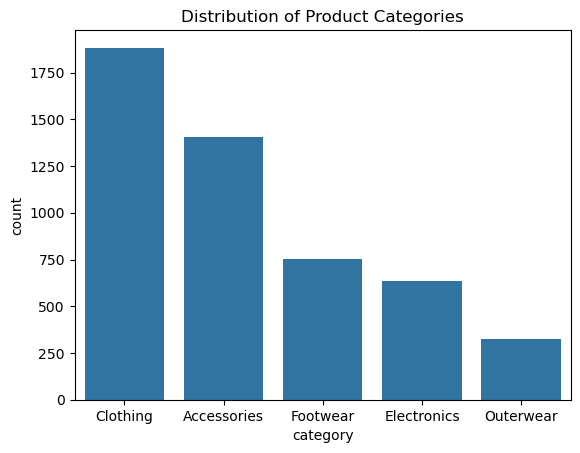

In [87]:
sns.countplot(data=df, x='category', order=df['category'].value_counts().index)
plt.title('Distribution of Product Categories')

#### How are Purchase amount distributes?
###### checking Outlier

Text(0.5, 1.0, 'Distribution of Purchase Amount (USD)')

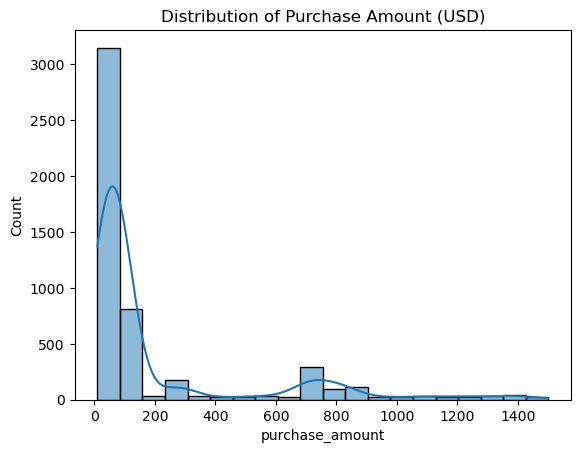

In [169]:
sns.histplot(df['purchase_amount'], kde=True, bins=20)
plt.title('Distribution of Purchase Amount (USD)')

##### What is the gender split of customers?

##### Pie Chart
###### Column: gender — quick proportion view.


Text(0.5, 1.0, 'Gender Distribution')

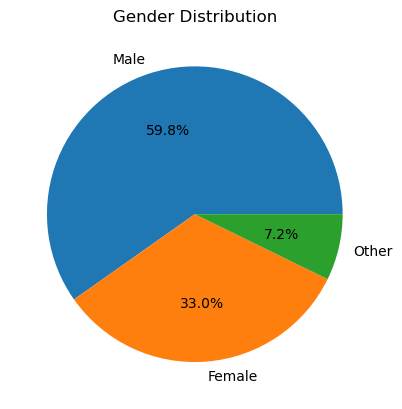

In [177]:
df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Gender Distribution')

#### Which season has the most purchases?

##### Bar / Countplot
###### Column: season — spot peak shopping seasons.

Text(0.5, 1.0, 'Purchases by Season')

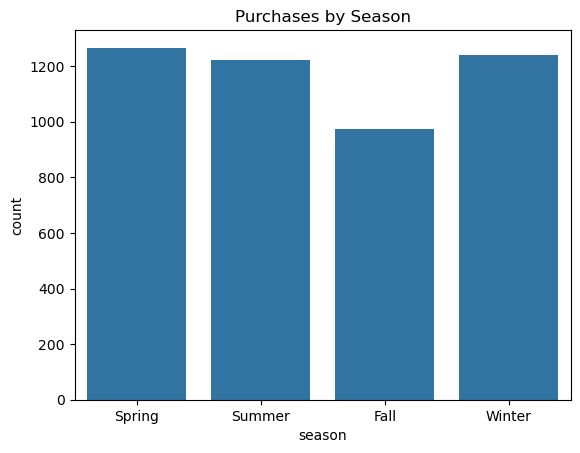

In [201]:
sns.countplot(data=df, x='season', order=['Spring','Summer','Fall','Winter'])
plt.title('Purchases by Season')

#### How are review ratings spread?

##### Histogram
###### Column: review_rating — are most customers happy (ratings 4–5)?

Text(0.5, 1.0, 'Distribution of Review Ratings')

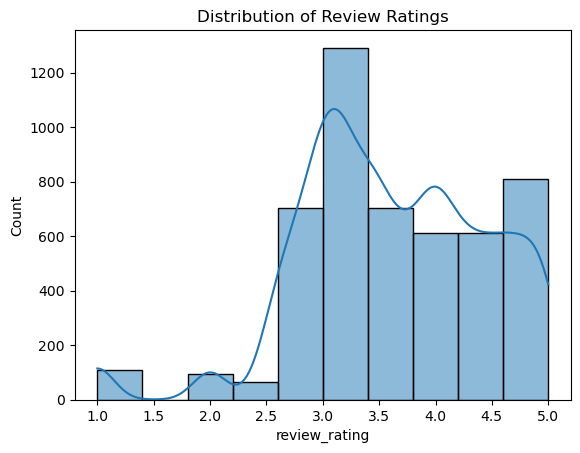

In [210]:
sns.histplot(df['review_rating'], bins=10, kde= True)
plt.title('Distribution of Review Ratings')

#### Which payment methods are most popular?

##### Horizontal Bar
###### Column: payment_method — Credit Card, PayPal, Cash, etc.

Text(0.5, 1.0, 'Payment Method Popularity')

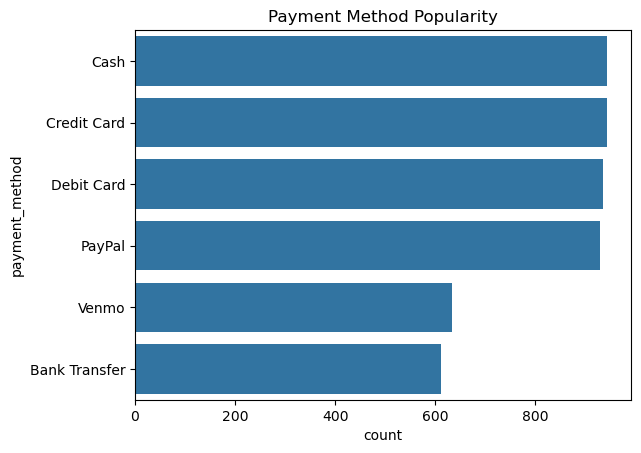

In [218]:
sns.countplot(data=df, y='payment_method', order=df['payment_method'].value_counts().index)
plt.title('Payment Method Popularity')

### 🔀 Bivariate Analysis — relationship between two columns

#### Which category generates highest spending?

##### Boxplot
###### Columns: category vs purchase_amount — compare median spend and outliers per category.

Text(0.5, 1.0, 'Purchase Amount by Category')

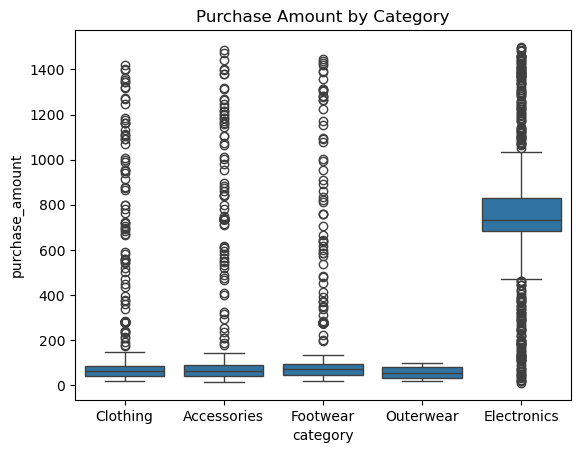

In [223]:
sns.boxplot(data=df, x='category', y='purchase_amount')
plt.title('Purchase Amount by Category')

#### Do male and female customers spend differently?

##### Barplot (mean)
###### Columns: gender vs purchase_amount — average spending by gender.

Text(0.5, 1.0, 'Avg Purchase Amount by Gender')

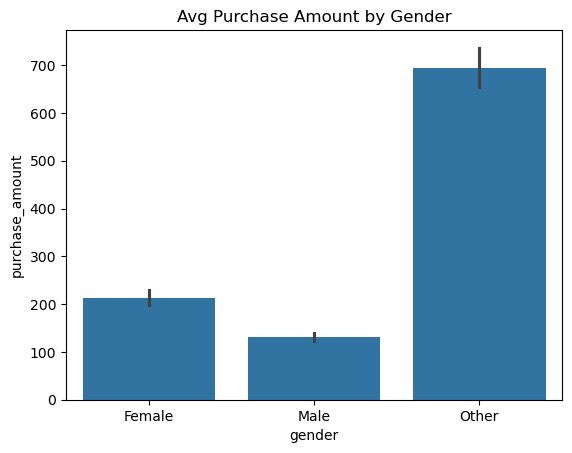

In [230]:
sns.barplot(data=df, x='gender', y='purchase_amount', estimator='mean')
plt.title('Avg Purchase Amount by Gender')

In [268]:
s = df.groupby('gender')['purchase_amount'].mean().reset_index()
print(s)

   gender  purchase_amount
0  Female       213.483930
1    Male       130.792238
2   Other       693.795580


#### Which category gets the best reviews?

##### Boxplot
###### Columns: category vs review_rating — satisfaction differs by product type.

Text(0.5, 1.0, 'Review Rating by Category')

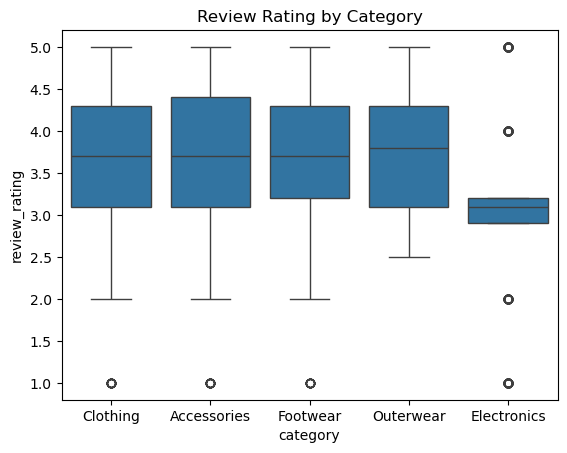

In [272]:
sns.boxplot(data=df, x='category', y='review_rating')
plt.title('Review Rating by Category')

#### What do people buy in each season?

##### Grouped Bar
###### Columns: season vs category — seasonal demand patterns per category.

Text(0.5, 1.0, 'Category Demand by Season')

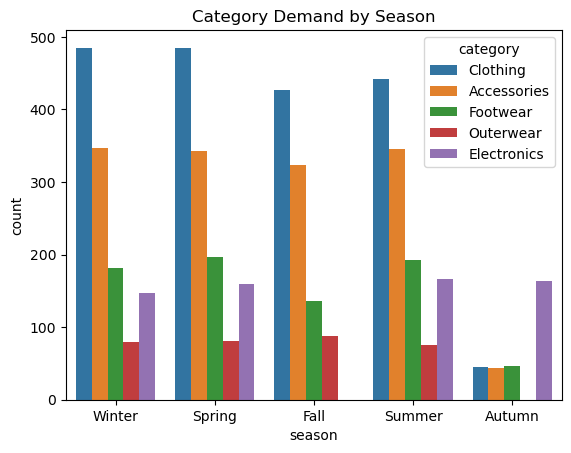

In [276]:
sns.countplot(data=df, x='season', hue='category')
plt.title('Category Demand by Season')

#### Do loyal customers spend more?

##### Scatter Plot
###### Columns: previous_purchases vs purchase_amount — loyalty vs spending correlation.



Text(0.5, 1.0, 'Loyalty vs Spending')

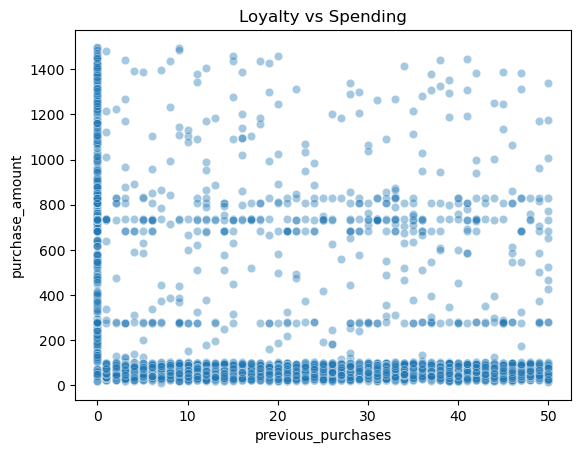

In [279]:
sns.scatterplot(data=df, x='previous_purchases', y='purchase_amount', alpha=0.4)
plt.title('Loyalty vs Spending')

#### Does payment method relate to satisfaction?

##### Bar (mean)
###### Columns: payment_method vs review_rating — interesting behavioral insight.

Text(0.5, 1.0, 'Avg Rating by Payment Method')

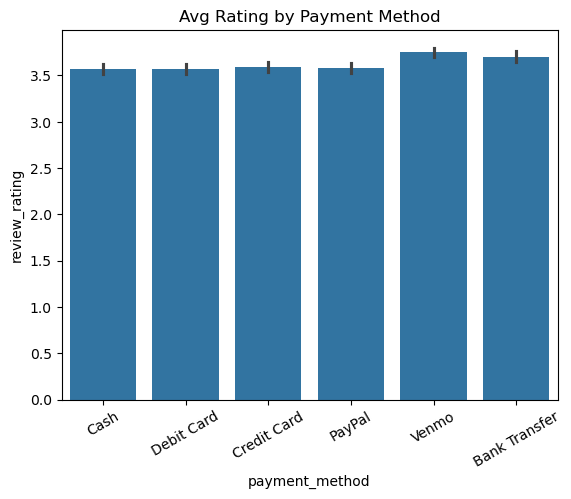

In [288]:
sns.barplot(data=df, x='payment_method', y='review_rating')
plt.xticks(rotation=30)
plt.title('Avg Rating by Payment Method')

### 🧩 Multivariate Analysis — 3+ columns together

#### Which numeric columns are correlated?
##### FacetGrid
###### Columns: season + category + purchase_amount — 3-way breakdown.

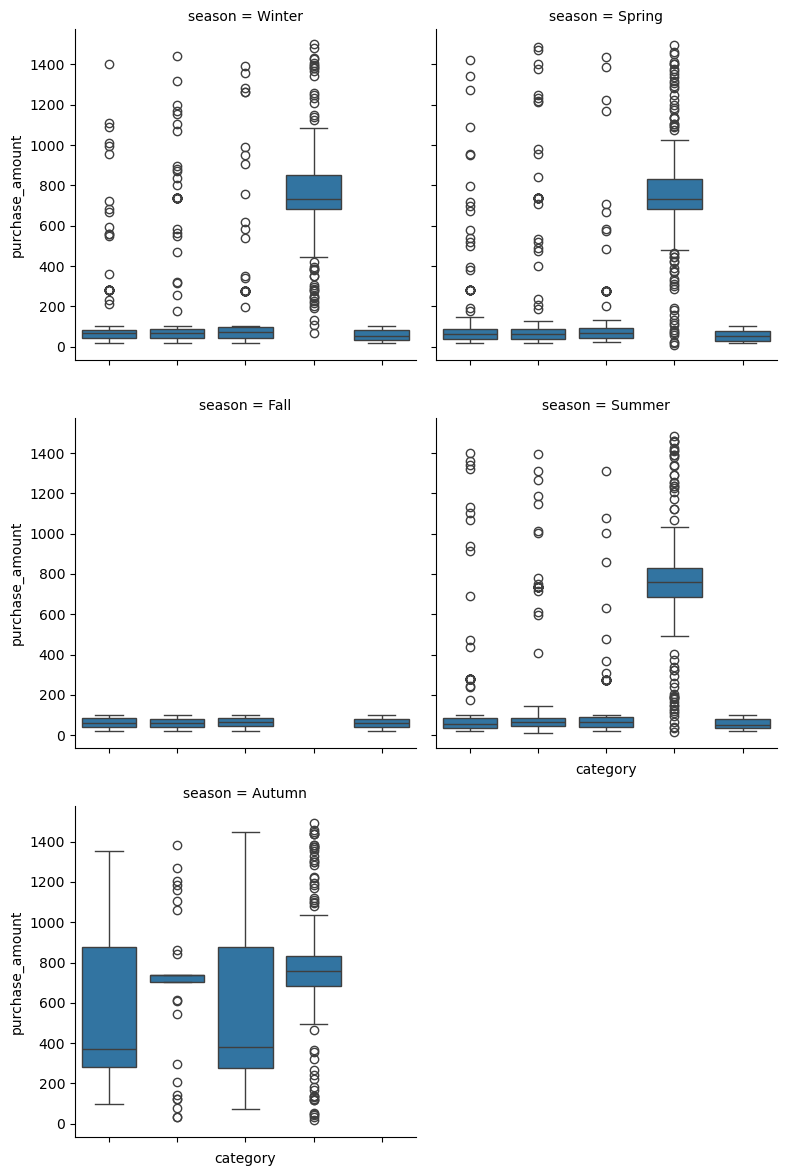

In [293]:
g = sns.FacetGrid(df, col='season', col_wrap=2, height=4)
g.map_dataframe(sns.boxplot, x='category', y='purchase_amount')
g.set_xticklabels(rotation=30)


#### Which season-category combo sells the most?

#### FacetGrid
###### Columns: season + category + purchase_amount — 3-way breakdown.

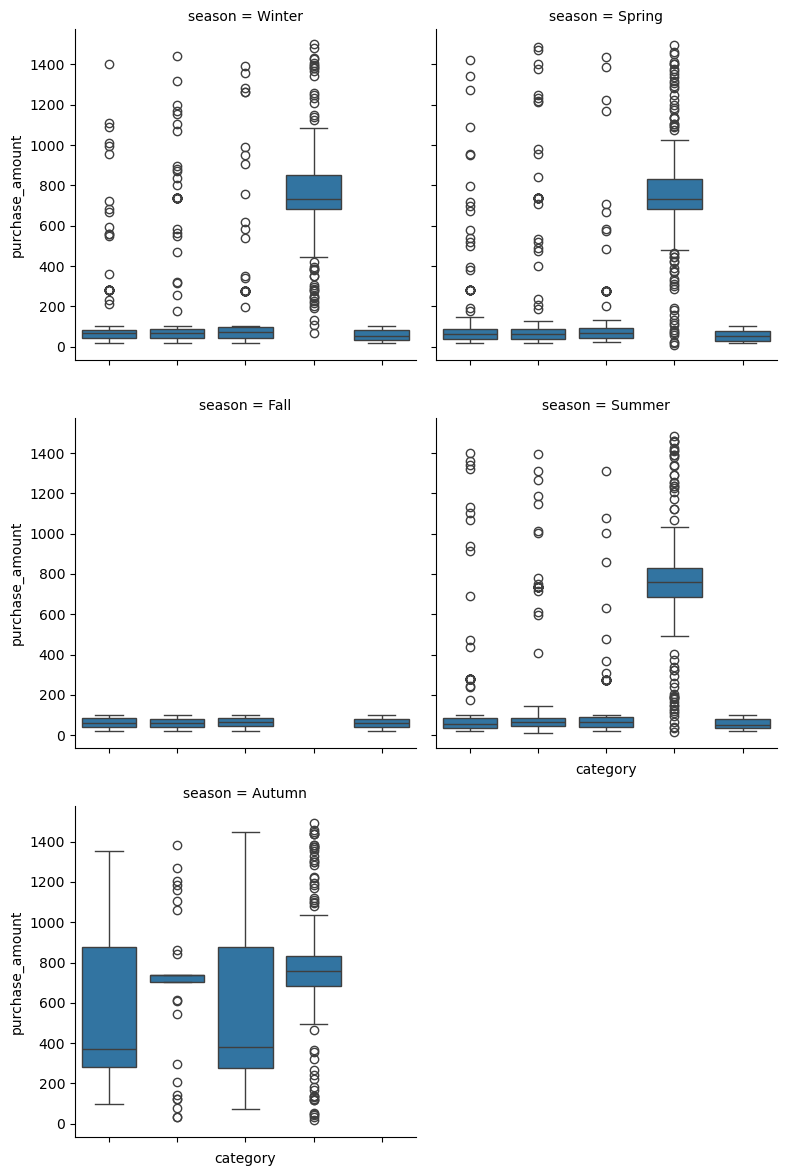

In [296]:
g = sns.FacetGrid(df, col='season', col_wrap=2, height=4)
g.map_dataframe(sns.boxplot, x='category', y='purchase_amount')
g.set_xticklabels(rotation=30)

#### Which season-category combo sells the most?

##### Pivot Heatmap
###### Columns: season + category — pivot table as heatmap.

Text(0.5, 1.0, 'Purchase Count: Season × Category')

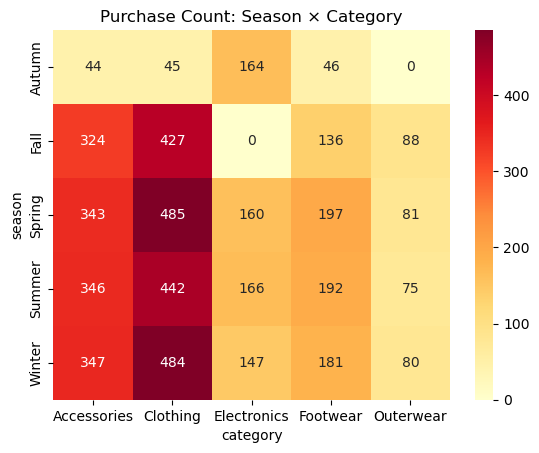

In [299]:
pivot = df.pivot_table(index='season', columns='category', aggfunc='size', fill_value=0)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Purchase Count: Season × Category')

#### Does loyalty + gender together explain spending?

##### Scatter + Hue
###### Columns: previous_purchases + purchase_amount + gender.

Text(0.5, 1.0, 'Spending vs Loyalty by Gender')

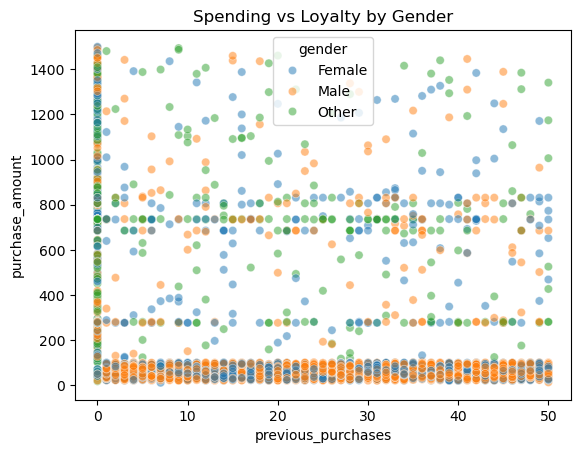

In [306]:
sns.scatterplot(data=df, x='previous_purchases', y='purchase_amount', hue='gender', alpha=0.5,)
plt.title('Spending vs Loyalty by Gender')

#### Overall relationships between all numeric features?

##### Pairplot
###### Columns: all numeric + gender as hue — great for project overview slide.

Text(0.5, 1.02, 'Pairplot: Numeric Features')

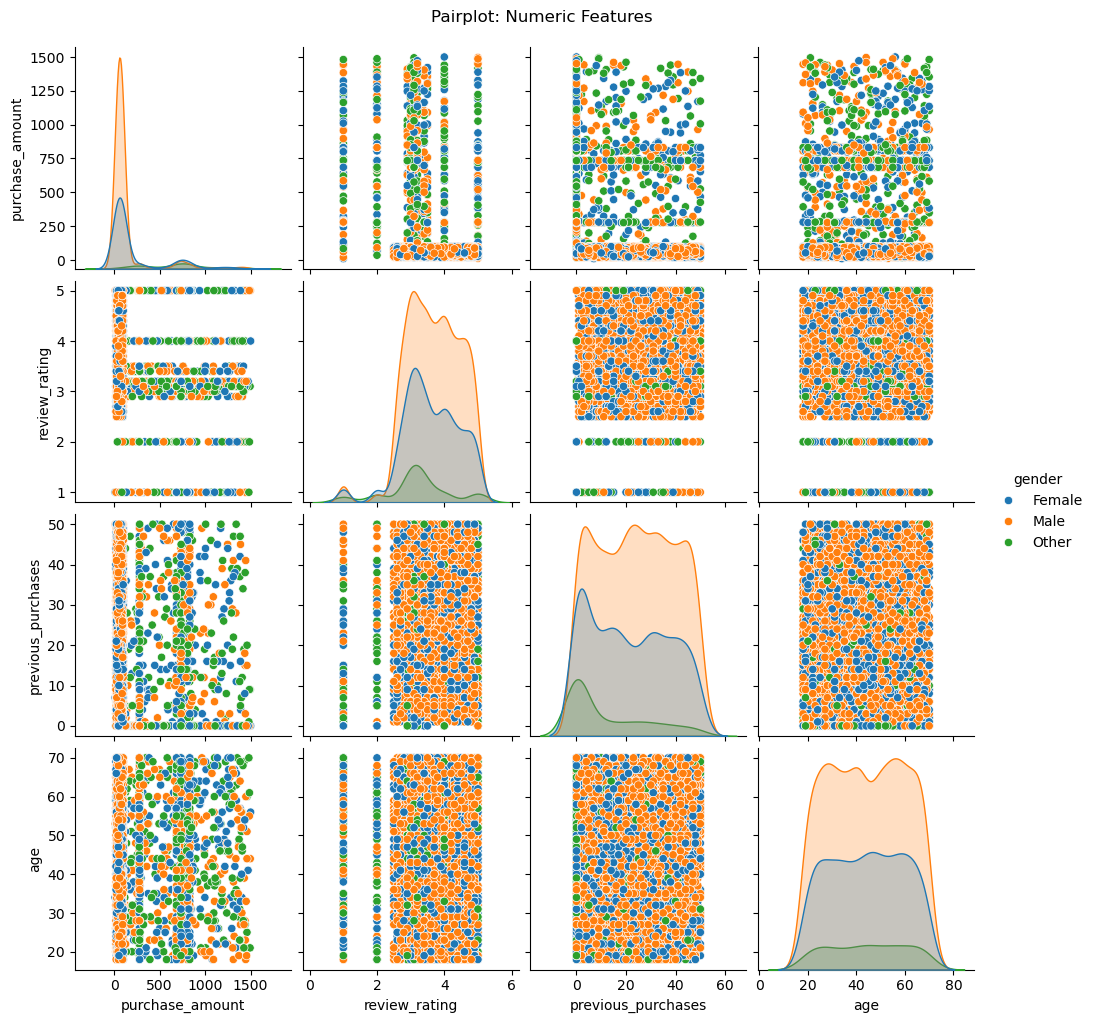

In [309]:
sns.pairplot(df[['purchase_amount','review_rating','previous_purchases','age','gender']], hue='gender')
plt.suptitle('Pairplot: Numeric Features', y=1.02)

# 📊 Executive Summary: Strategic Recommendations for the Business Owner

### Dear Store Owner,

Following a deep dive into our customer transaction history (5,000 unique customer profiles analyzed after data cleaning), we have uncovered clear operational quick-wins and revenue opportunities. Below are the key data-driven insights and my strategic recommendations:

---

### 1. Fix the "High Revenue, Low Satisfaction" Vulnerability
* **The Data Finding:** Your `groupby` analysis reveals that **Bags** (averaging \$735 per purchase) and **Headphones** (averaging \$831 per purchase) generate your highest transaction values. However, they also hold the **lowest review ratings** in the store (Bags: 3.16/5, Headphones: 3.07/5), which sits well below the store average of 3.66.
* **The Suggestion:** **Audit your suppliers for Electronics and Bags immediately.** Customers are willing to spend premium dollars on these items, but the low ratings point to quality issues, false advertising, or shipping delays. Fixing these product defects will protect your brand reputation and prevent expensive return costs.

### 2. Personalize Marketing for High-Spending Demographics
* **The Data Finding:** The gender distribution analysis highlights a dramatic disparity in spending power. While male customers spend an average of \$130.79, female customers spend significantly more at **\$213.48**, and customers identifying as "Other" average an outstanding **\$693.80** per transaction.
* **The Suggestion:** **Reallocate your ad spend.** Rather than running generic marketing campaigns, design targeted segments tailored around your high-value audiences. Create personalized email campaigns, curate targeted lookbooks for your premium spenders, and ensure inventory levels mirror this high-tier demand.

### 3. Restructure Pricing Tiers for Core Categories
* **The Data Finding:** The category boxplots show that for Clothing, Accessories, and Footwear, the middle 50% of your shoppers consistently spend under \$100. However, there is a dense wall of outlier transactions stretching all the way up to **\$1,500**.
* **The Suggestion:** **Formally introduce an "Everyday Essentials" vs. "Premium/Luxury" inventory tier.** Because your core business relies heavily on volume under \$100, treating \$1,500 outlier purchases within the same bucket skews your financial forecasting. Separating luxury items from core inventory will keep inventory predictions stable.

### 4. Optimize Seasonal Stock Matching
* **The Data Finding:** The pivot table heatmaps (`Season × Category`) indicate clear, predictable seasonal wave behaviors in sales volume.
* **The Suggestion:** **Synchronize stock cycles with your seasonality heatmap.** Ensure that lower-rated or slower-moving items are cleared out via promotional bundles (e.g., pairing a low-rated Bag with a highly-rated pair of Boots or Gloves) right before transition periods to keep warehouse turnover high.

### 5. Standardize Data Collection & Prevent Duplicate Loss
* **The Data Finding:** The data cleaning phase uncovered 50 absolute duplicate transactions, hundreds of missing values for sizes/purchase amounts, and mismatched category definitions (like Laptops accidentally mixed into Clothing lines).
* **The Suggestion:** **Upgrade the data validation rules on your e-commerce platform.** Restrict product mapping to structured drop-down menus instead of free-text inputs, and introduce an automatic deduplication checkpoint during checkout to keep sales metrics clean and trustworthy.